In [1]:
# 1. Check for GPU
# ImageBind requires a GPU to run efficiently.
import torch
if not torch.cuda.is_available():
    raise SystemError("GPU is not detected. Go to Runtime > Change Runtime Type > Select T4 GPU.")
print(f"GPU Detected: {torch.cuda.get_device_name(0)}")

GPU Detected: Tesla T4


In [2]:
# 2. Install ImageBind and Dependencies
# We use specific versions to ensure compatibility with Colab's default environment
!git clone https://github.com/facebookresearch/ImageBind.git
%cd ImageBind
!pip install -r requirements.txt
!pip install timm==0.6.13 # Specific version required for ImageBind

Cloning into 'ImageBind'...
remote: Enumerating objects: 187, done.
remote: Counting objects: 100% (120/120), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 187 (delta 84), reused 54 (delta 53), pack-reused 67 (from 3)
Receiving objects: 100% (187/187), 2.65 MiB | 6.51 MiB/s, done.
Resolving deltas: 100% (92/92), done.
/content/ImageBind
  Cloning https://github.com/facebookresearch/pytorchvideo.git (to revision 6cdc929315aab1b5674b6dcf73b16ec99147735f) to /tmp/pip-install-mgx9jt1b/pytorchvideo_2afe836b67ed4e8f8523da5b0c7bafd1
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/pytorchvideo.git /tmp/pip-install-mgx9jt1b/pytorchvideo_2afe836b67ed4e8f8523da5b0c7bafd1
  Running command git rev-parse -q --verify 'sha^6cdc929315aab1b5674b6dcf73b16ec99147735f'
  Running command git fetch -q https://github.com/facebookresearch/pytorchvideo.git 6cdc929315aab1b5674b6dcf73b16ec99147735f
  Running command git checkout -q 6cdc929315aab1b

In [7]:
import os
import requests
from PIL import Image
from io import BytesIO
import shutil

# 1. Clean up old/corrupted data
if os.path.exists(".data"):
    shutil.rmtree(".data")
os.makedirs(".data", exist_ok=True)

# 2. Define URLs
image_urls = {
    "dog_1": "https://upload.wikimedia.org/wikipedia/commons/9/90/Labrador_Retriever_portrait.jpg",
    "dog_2": "https://upload.wikimedia.org/wikipedia/commons/4/47/American_Eskimo_Dog.jpg",
    "dog_3": "https://upload.wikimedia.org/wikipedia/commons/f/f8/Full_attention_%288067543690%29.jpg",

    "car_1": "https://upload.wikimedia.org/wikipedia/commons/a/a4/2019_Toyota_Corolla_Icon_Tech_VVT-i_Hybrid_1.8.jpg",
    "car_2": "https://upload.wikimedia.org/wikipedia/commons/6/6d/2017_Honda_Civic_EX_VTEC_CVT_1.0_Front.jpg",
    "car_3": "https://upload.wikimedia.org/wikipedia/commons/f/f2/1986_Ferrari_Testarossa.jpg",

    "fruit_1": "https://upload.wikimedia.org/wikipedia/commons/2/2f/Culinary_fruits_front_view.jpg",
    "fruit_2": "https://upload.wikimedia.org/wikipedia/commons/8/8a/Banana-Single.jpg",
    "fruit_3": "https://upload.wikimedia.org/wikipedia/commons/c/c4/Orange-Fruit-Pieces.jpg"
}

# 3. Download with Headers (CRITICAL FIX)
# Many sites block requests without a User-Agent
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

image_paths = []
labels_true = []

print("Downloading images...")
for name, url in image_urls.items():
    try:
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status() # Check for 403/404 errors

        img_path = f".data/{name}.jpg"

        # Save file
        with open(img_path, 'wb') as f:
            f.write(response.content)

        # Verify it is actually an image immediately
        try:
            with Image.open(img_path) as img:
                img.verify() # This checks if the file is corrupted
            image_paths.append(img_path)
            labels_true.append(name.split('_')[0])
            print(f" - Downloaded & Verified: {name}")
        except Exception as e:
            print(f" - FAILED to verify {name}: {e}")

    except Exception as e:
        print(f" - Error downloading {name}: {e}")

print(f"\nSuccessfully prepared {len(image_paths)} images.")

 - Downloaded & Verified: dog_1
 - Downloaded & Verified: dog_2
 - Downloaded & Verified: dog_3
 - Downloaded & Verified: car_1
 - Error downloading car_2: 404 Client Error: Not Found for url: https://upload.wikimedia.org/wikipedia/commons/6/6d/2017_Honda_Civic_EX_VTEC_CVT_1.0_Front.jpg
 - Error downloading car_3: 404 Client Error: Not Found for url: https://upload.wikimedia.org/wikipedia/commons/f/f2/1986_Ferrari_Testarossa.jpg
 - Downloaded & Verified: fruit_1
 - Downloaded & Verified: fruit_2
 - Downloaded & Verified: fruit_3

Successfully prepared 7 images.


In [8]:
import sys
import os

# Ensure ImageBind is in the python path
if '/content/ImageBind' not in sys.path:
    sys.path.append('/content/ImageBind')

# Fix: Install a compatible version of timm (ImageBind code requires timm.layers which is in newer versions)
!pip install timm --upgrade

import torch
from imagebind import data
from imagebind.models import imagebind_model
from imagebind.models.imagebind_model import ModalityType

# 1. Load the Model
print("Loading ImageBind Model (this takes a minute)...")
device = "cuda" if torch.cuda.is_available() else "cpu"
model = imagebind_model.imagebind_huge(pretrained=True)
model.eval()
model.to(device)

# 2. Process Images
# ImageBind requires specific preprocessing (handled by data.load_and_transform_vision_data)
inputs = {
    ModalityType.VISION: data.load_and_transform_vision_data(image_paths, device)
}

# 3. Generate Embeddings
print("Encoding images...")
with torch.no_grad():
    embeddings_dict = model(inputs)

# Extract the vision embeddings and move to CPU for clustering
embeddings = embeddings_dict[ModalityType.VISION].cpu().numpy()

print(f"Embeddings Shape: {embeddings.shape} (Samples x Vector_Dim)")
# ImageBind Huge usually outputs 1024-dimensional vectors

Loading ImageBind Model (this takes a minute)...
Encoding images...
Embeddings Shape: (7, 1024) (Samples x Vector_Dim)


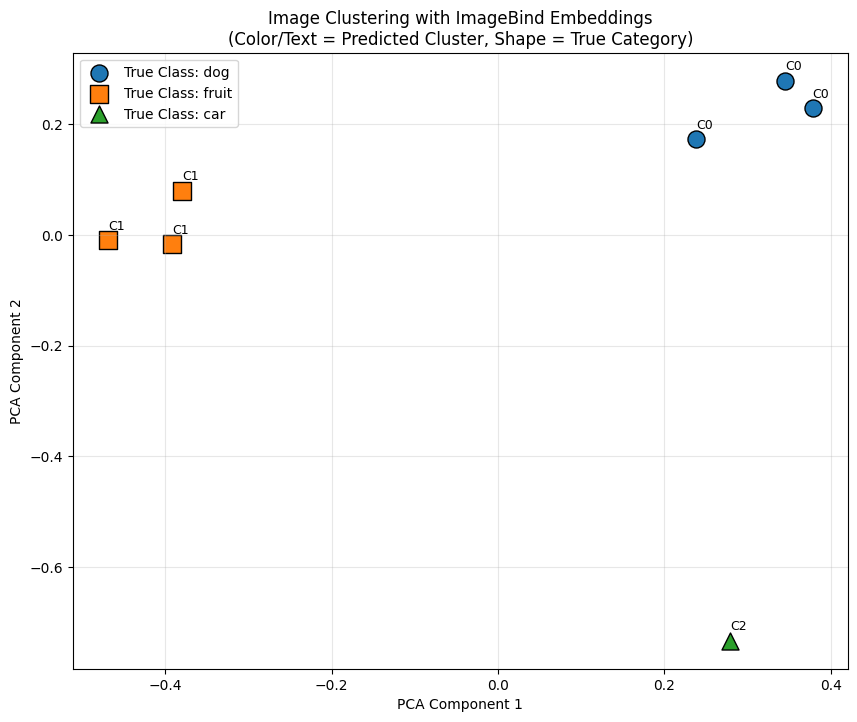

Interpretation:
Points with the same SHAPE belong to the same real-world category.
Points grouped close together were seen as 'similar' by ImageBind.


In [9]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 1. Clustering
# We expect 3 clusters (Dogs, Cars, Fruit)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(embeddings)
labels_pred = kmeans.labels_

# 2. Dimensionality Reduction (1024 dim -> 2 dim)
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# 3. Visualization
plt.figure(figsize=(10, 8))

# Define colors for the true labels (to verify if clustering worked)
# Note: KMeans assigns random IDs (0,1,2), they might not match our category order,
# but the *grouping* should be correct.
unique_labels = list(set(labels_true))
markers = ['o', 's', '^'] # Circle, Square, Triangle

for i, label in enumerate(unique_labels):
    # Find indices of this true category
    indices = [idx for idx, l in enumerate(labels_true) if l == label]

    # Plot these points
    # We color them by the KMEANS PREDICTION to see if the model got it right
    # If the model works, all 'dogs' should have the same color.
    points = reduced_embeddings[indices]
    plt.scatter(points[:, 0], points[:, 1],
                s=150,
                marker=markers[i],
                label=f"True Class: {label}",
                edgecolors='black')

    # Annotate with the predicted cluster ID
    for j, point in enumerate(points):
        pred_cluster = labels_pred[indices[j]]
        plt.text(point[0], point[1]+0.02, f"C{pred_cluster}", fontsize=9)

plt.title("Image Clustering with ImageBind Embeddings\n(Color/Text = Predicted Cluster, Shape = True Category)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Interpretation:")
print("Points with the same SHAPE belong to the same real-world category.")
print("Points grouped close together were seen as 'similar' by ImageBind.")